In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load the dataset
data = pd.read_csv('Documents/MASTER 2024/Summer 2024/Practical Data Analytics/real_estate_value.csv')  # Update with the correct path

# Split the data into features and target
X = data.drop(columns=['UnitPrice'])
y = data['UnitPrice']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the size of the training data
data_size = X_train.shape[0]

print(f'Training set size: {X_train.shape}')
print(f'Testing set size: {X_test.shape}')

Training set size: (331, 5)
Testing set size: (83, 5)


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define numeric and categorical columns
num_cols = ['HouseAge', 'DistanceToMRT', 'Latitude', 'Longitude']
cat_cols = ['NoOfStores']

# Define preprocessing pipelines
# For numeric columns:
# 1. Impute missing values using the median value
#    Justification: The median is robust to outliers and provides a better central value for imputation compared to the mean in skewed distributions.
# 2. Standardize features by removing the mean and scaling to unit variance
#    Justification: Standardizing ensures that each feature contributes equally to the model, preventing features with larger magnitudes from dominating the learning process.
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('standardize', StandardScaler())
])

# For categorical columns:
# 1. Impute missing values using the most frequent value
#    Justification: For categorical data, using the most frequent value is a common imputation strategy as it maintains the mode of the data distribution.
# 2. One-hot encode the categorical columns
#    Justification: One-hot encoding converts categorical variables into a binary matrix representation, which is required for models that cannot handle categorical variables directly.

cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder())
])

# Combine both pipelines into a single ColumnTransformer
process_pipeline = ColumnTransformer([
    ('numeric', num_pipeline, num_cols),
    ('categorical', cat_pipeline, cat_cols)
])

# Fit and transform the training data
X_train_processed = process_pipeline.fit_transform(X_train)
X_test_processed = process_pipeline.transform(X_test)

# Calculate the number of features after preprocessing
n_features = X_train_processed.shape[1]

Best estimator for Decision Tree: Pipeline(steps=[('processing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardize',
                                                                   StandardScaler())]),
                                                  ['HouseAge', 'DistanceToMRT',
                                                   'Latitude', 'Longitude']),
                                                 ('categorical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                       

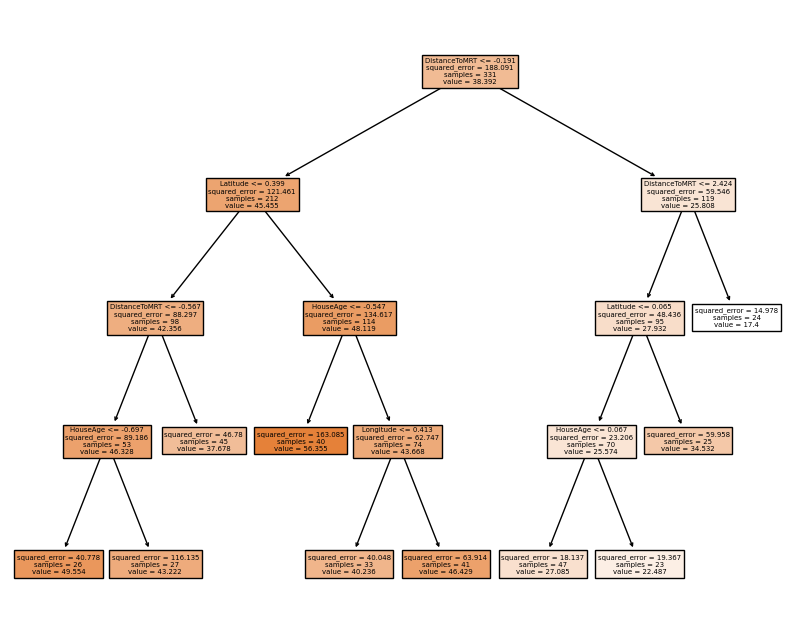

In [11]:
import matplotlib.pyplot as plt  # Add this import statement

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV

# Define the Decision Tree model pipeline
dtc = Pipeline([
    ('processing', process_pipeline),
    ('dtc', DecisionTreeRegressor())
])

# Define the parameter grid for hyperparameter tuning
param_grid_dt = {
    'dtc__max_depth': [3, 4],
    'dtc__min_samples_split': [data_size//15, data_size//10],
    'dtc__min_samples_leaf': [data_size//15, data_size//10],
    'dtc__max_features': [n_features//3, n_features//2],
    'dtc__max_leaf_nodes': [10, 15]
}

# Perform Grid Search with 5-fold cross-validation
grid_search_dt = GridSearchCV(dtc, param_grid_dt, cv=5, scoring='r2', return_train_score=True)
grid_search_dt.fit(X_train, y_train)

# Output the best estimator and scores for the Decision Tree
print("Best estimator for Decision Tree:", grid_search_dt.best_estimator_)
print("Best R^2 score for Decision Tree:", grid_search_dt.best_score_)
print("Test R^2 score for Decision Tree:", grid_search_dt.score(X_test, y_test))

# Visualize the decision tree
best_dtc = grid_search_dt.best_estimator_.named_steps['dtc']
plt.figure(figsize=(10, 8))
plot_tree(best_dtc, filled=True, feature_names=num_cols + list(process_pipeline.named_transformers_['categorical'].named_steps['encode'].get_feature_names_out(cat_cols)))
plt.show()

Best estimator for Random Forest: Pipeline(steps=[('processing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardize',
                                                                   StandardScaler())]),
                                                  ['HouseAge', 'DistanceToMRT',
                                                   'Latitude', 'Longitude']),
                                                 ('categorical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                       

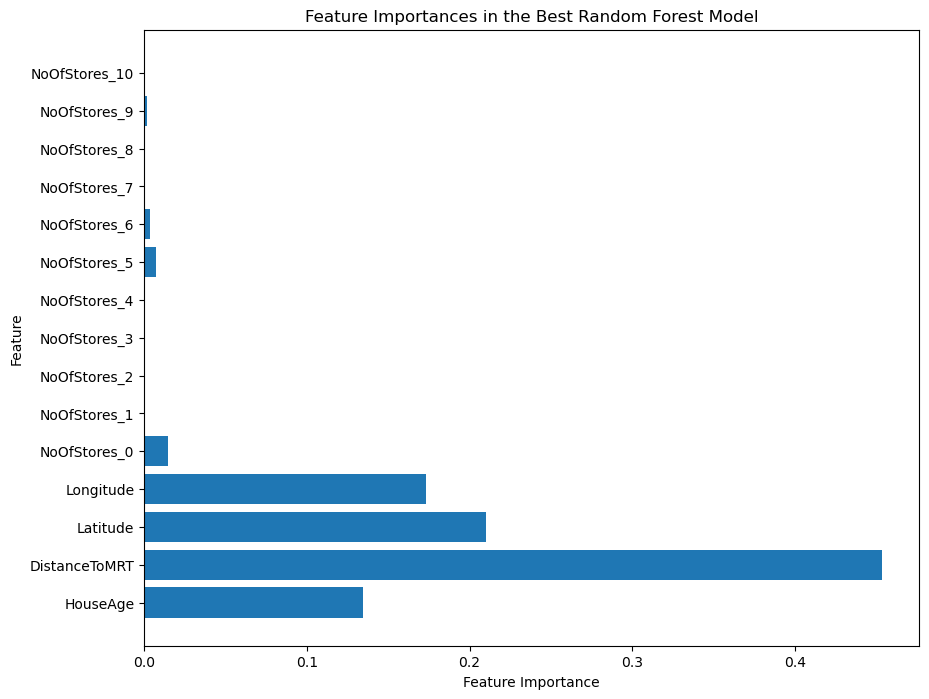

In [12]:
import matplotlib.pyplot as plt  # Ensure matplotlib is imported if not already

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Define the Random Forest model pipeline
rfr = Pipeline([
    ('processing', process_pipeline),
    ('rfr', RandomForestRegressor())
])

# Define the parameter grid for hyperparameter tuning
param_grid_rf = {
    'rfr__n_estimators': [10, 25],
    'rfr__max_depth': [4, 5],
    'rfr__min_samples_split': [data_size//25, data_size//15],
    'rfr__min_samples_leaf': [data_size//25, data_size//15],
    'rfr__max_features': [n_features//3, n_features//2],
    'rfr__max_leaf_nodes': [10, 15]
}

# Perform Grid Search with 5-fold cross-validation
grid_search_rf = GridSearchCV(rfr, param_grid_rf, cv=5, scoring='r2', return_train_score=True)
grid_search_rf.fit(X_train, y_train)

# Output the best estimator and scores for the Random Forest
print("Best estimator for Random Forest:", grid_search_rf.best_estimator_)
print("Best R^2 score for Random Forest:", grid_search_rf.best_score_)
print("Test R^2 score for Random Forest:", grid_search_rf.score(X_test, y_test))

# Visualization for Random Forest is not typically a single tree, but we can visualize feature importances
best_rfr = grid_search_rf.best_estimator_.named_steps['rfr']
importances = best_rfr.feature_importances_
feature_names = num_cols + list(process_pipeline.named_transformers_['categorical'].named_steps['encode'].get_feature_names_out(cat_cols))

# Plotting the feature importances
plt.figure(figsize=(10, 8))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importances in the Best Random Forest Model")
plt.show()